#### Census Income Data Visualization

#### About this file:
This file contains data visualization tasks using census-income dataset. It contains:

**Data Manipulation:**
- Changing name of one column to another
- Removing the space before columns
- renaming the columns.

**Visualization plots:**
- kde plot
- count plot
- Boxplot
- Barplot
- Heatmap
- pairplot
- Violin plot

In [1]:
# Load necessary libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("census-income.csv")

In [3]:
df.shape

(32561, 15)

##### Changing the name of column from species to species name
species_name = df['species'].apply(lambda x : x.split(' ')[0])
df.insert(4,"species_name",species_name)
df.drop(['species'],axis=1,inplace=True)
df.head()

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              32561 non-null  int64 
 1    workclass       32561 non-null  object
 2    fnlwgt          32561 non-null  int64 
 3    education       32561 non-null  object
 4    education-num   32561 non-null  int64 
 5    marital-status  32561 non-null  object
 6    occupation      32561 non-null  object
 7    relationship    32561 non-null  object
 8    race            32561 non-null  object
 9    sex             32561 non-null  object
 10   capital-gain    32561 non-null  int64 
 11   capital-loss    32561 non-null  int64 
 12   hours-per-week  32561 non-null  int64 
 13   native-country  32561 non-null  object
 14                   32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
# Null Check
df.isnull().sum().sum()

0

In [ ]:
# Duplicate Check
df.duplicated().sum()

24

In [ ]:
# Display rows with duplicate values
df[df.duplicated()]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,
4881,25,Private,308144,Bachelors,13,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,Mexico,<=50K
5104,90,Private,52386,Some-college,10,Never-married,Other-service,Not-in-family,Asian-Pac-Islander,Male,0,0,35,United-States,<=50K
9171,21,Private,250051,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,10,United-States,<=50K
11631,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K
13084,25,Private,195994,1st-4th,2,Never-married,Priv-house-serv,Not-in-family,White,Female,0,0,40,Guatemala,<=50K
15059,21,Private,243368,Preschool,1,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,50,Mexico,<=50K
17040,46,Private,173243,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
18555,30,Private,144593,HS-grad,9,Never-married,Other-service,Not-in-family,Black,Male,0,0,40,?,<=50K
18698,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
21318,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K


In [ ]:
# Statistical summary of the data
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
# Display column names
df.columns

Index(['age', ' workclass', ' fnlwgt', ' education', ' education-num',
       ' marital-status', ' occupation', ' relationship', ' race', ' sex',
       ' capital-gain', ' capital-loss', ' hours-per-week', ' native-country',
       ' '],
      dtype='object')

In [ ]:
# Remove the space before the columns
df.columns = df.columns.str.strip()
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', ''],
      dtype='object')

In [11]:
# raname the target column
df.rename(columns = {df.columns[-1]: "income"}, inplace = True)

In [14]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


#### Visualization

#### Q1. Distribution of age columns using kde plot.

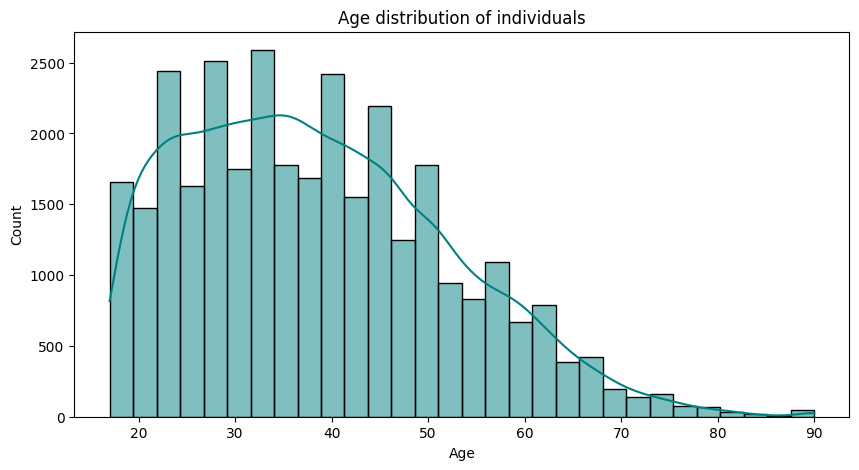

In [15]:
plt.figure(figsize = (10, 5))

sns.histplot(df["age"], kde = True, bins = 30, color = "teal")

plt.title("Age distribution of individuals")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

**Insights:**
- Age columns following right-skewed distribution. Most individuals are between 25 to 50 years old, with peaks around age 30 and 40. This kde line helps us to see density trends.

#### Q2. Income distribution by gender.

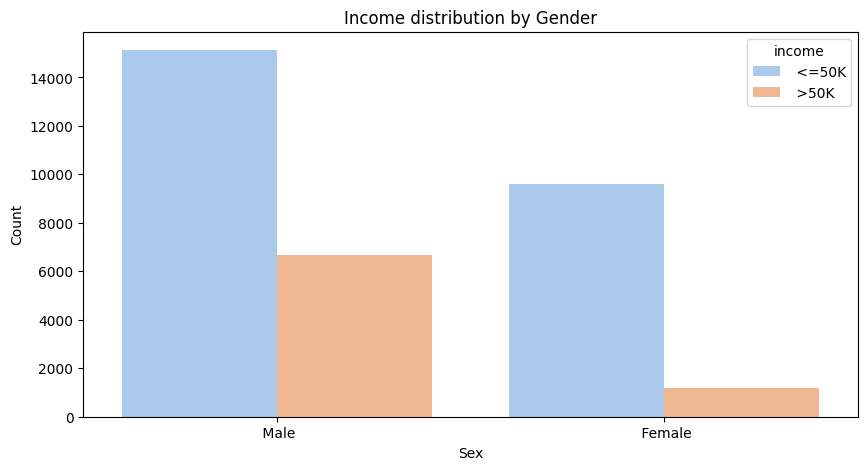

In [16]:
plt.figure(figsize = (10, 5))

sns.countplot(x = "sex", hue = 'income', data = df, palette = 'pastel')
plt.title("Income distribution by Gender")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

**Insights:**
- A larger number of males are earning more than 50k compared to females, it indicates potential gender disparity in income distribution.

#### Q3. Boxplot of Hours worked per week by Income.

In [18]:
import warnings
warnings.filterwarnings("ignore")

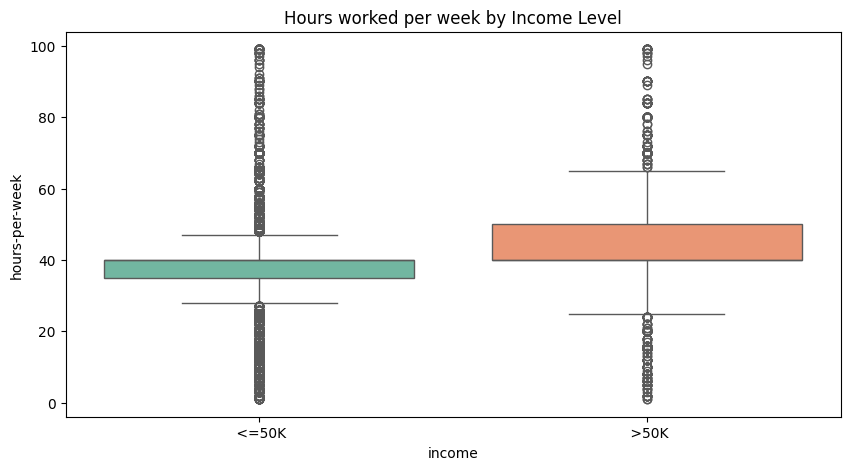

In [19]:
plt.figure(figsize = (10, 5))

sns.boxplot(x = 'income', y = 'hours-per-week', data = df, palette = 'Set2')
plt.title("Hours worked per week by Income Level")
plt.show()

**Insights:**
- Those earning >50K tend to work longer hours, but the distribution shows high variance especially among lower income individuals.

#### Q4. Average education level by income using Barplot.

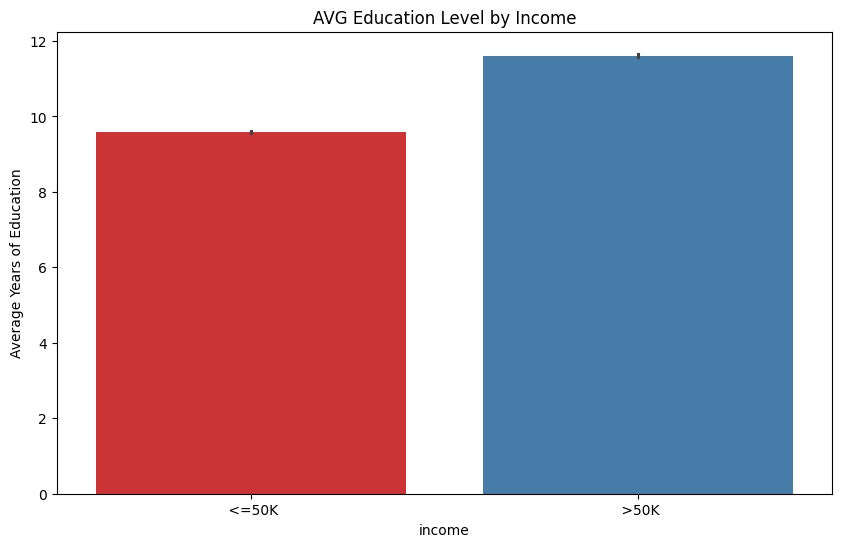

In [20]:
plt.figure(figsize = (10, 6))

sns.barplot(x = 'income', y = "education-num", data = df, palette = 'Set1')
plt.title("AVG Education Level by Income")
plt.ylabel("Average Years of Education")
plt.show()

**Insight:**
- People with higher income generally have high levels of education indicating education's strong influence on income potential.

#### Q5. Feature correlation using Heatmap.

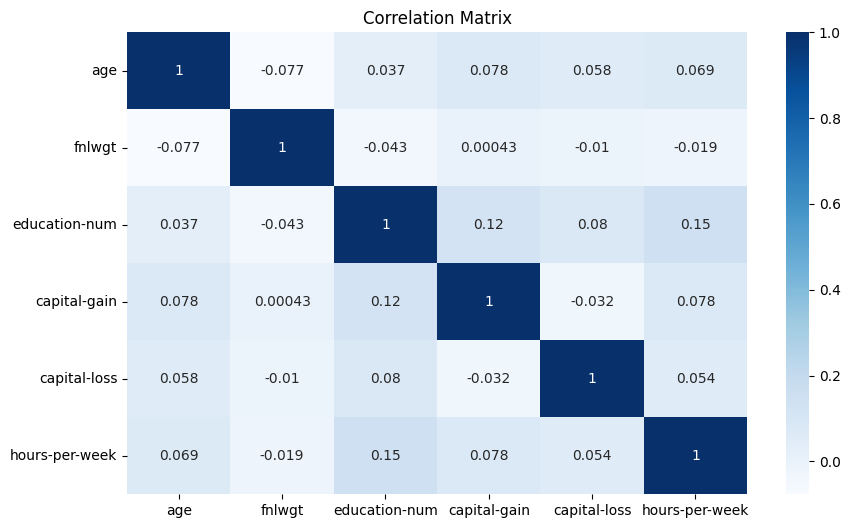

In [21]:
plt.figure(figsize = (10, 6))
corr = df.corr(numeric_only = True)
sns.heatmap(corr, annot = True, cmap = "Blues")
plt.title("Correlation Matrix")
plt.show()

**Insights:**

- education-num and age have a mild positive correlation with hours-per-week and capital-gain.

- capital-gain and capital-loss have a negative relationship indicating alternate income mechanisms.

#### Q6. Distribution of work class by Income

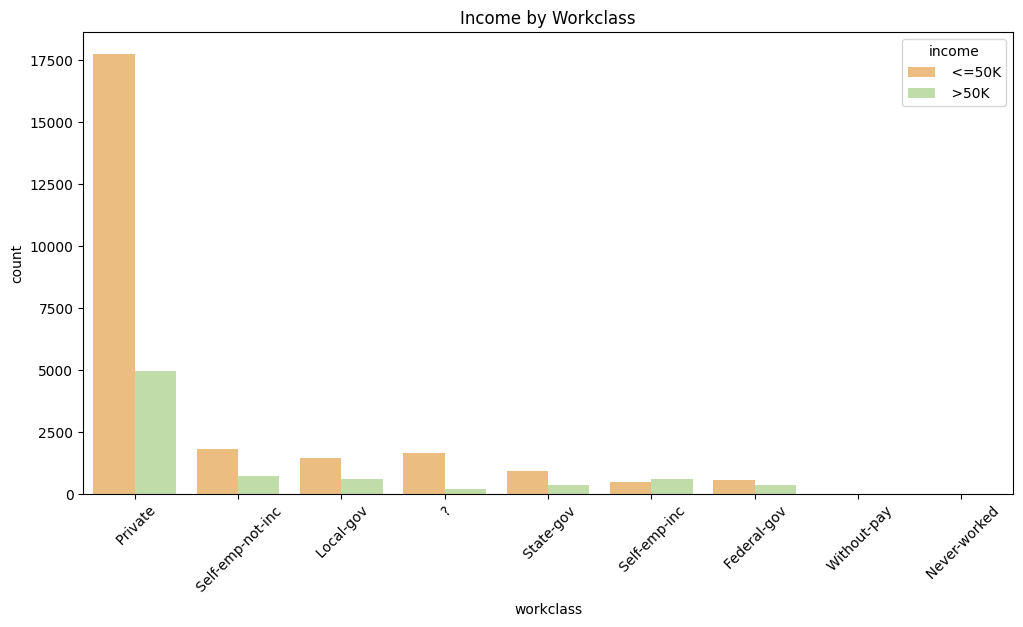

In [22]:
plt.figure(figsize = (12, 6))

sns.countplot(x = 'workclass', hue = 'income', data = df, order = df["workclass"].value_counts().index, palette = 'Spectral')
plt.title("Income by Workclass")
plt.xticks(rotation= 45)
plt.show()

**Insights:**
- Private sector is the largest employer but has high number of low income earners.
- Self employed and government jobs show relatively better income distributions.

#### Q7. Pairplot of Numeric features.

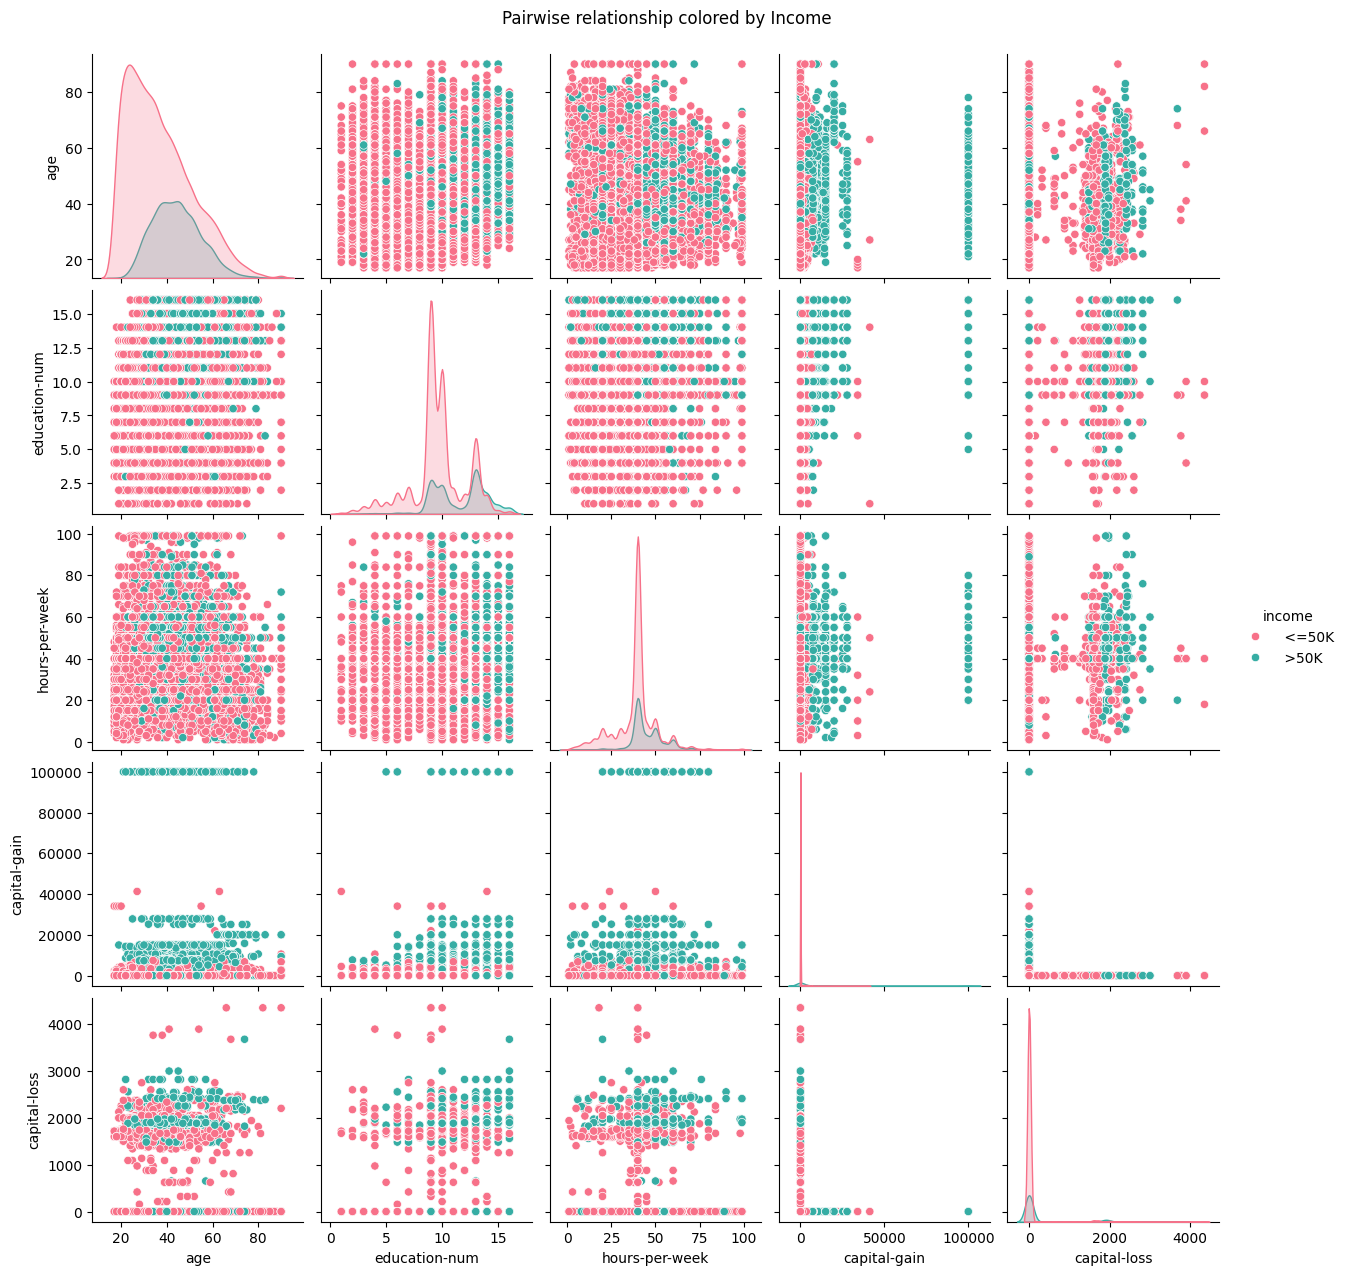

In [23]:
sns.pairplot(df[["age", "education-num", "hours-per-week", "capital-gain","capital-loss", "income"]], hue = 'income', palette = 'husl')
plt.suptitle("Pairwise relationship colored by Income", y = 1.02)
plt.show()

**Insights:**
- Clear clusters for capital-gain with high-income individuals.
- age and hours-per-week appear loosely correlated with income.

#### Q8. Violin Plot: Education vs Income.

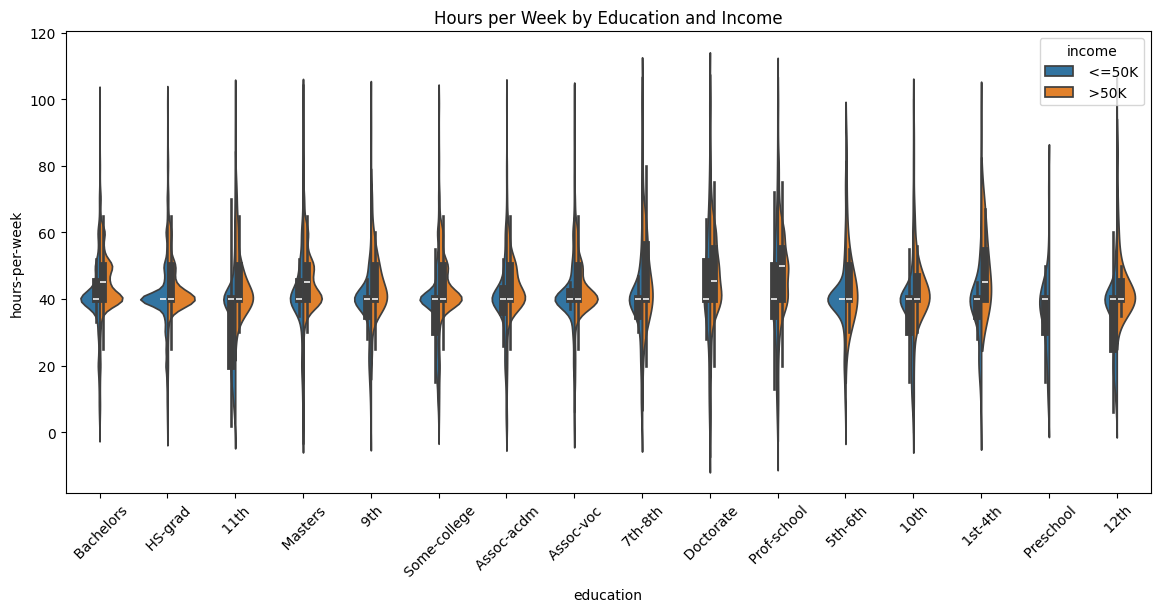

In [24]:
plt.figure(figsize=(14, 6))
sns.violinplot(x='education', y='hours-per-week', hue='income', data=df, split=True)
plt.xticks(rotation=45)
plt.title('Hours per Week by Education and Income')
plt.show()

**Insights:**
- People with advanced degrees (Masters/Doctorate) working more hours are more likely to earn >50K.